GLOBAL IMPORTS AND CONFIGS

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

#GLOBAL VARIABLES

randomState = 42
EPOCHS = 100
ARRAY_PATH = "processed_arrays/"

#CHECK CUDA AVAILABILITY

import torch
torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("CUDA Available:", torch.cuda.is_available())

CUDA Available: True


LOADING THE PREPROCESSED DATA

In [10]:
# TRAINING DATA
X_train_prep = np.load(
    ARRAY_PATH + "X_train.npy",
    allow_pickle=True
)

y_train = np.load(
    ARRAY_PATH + "y_train.npy",
    allow_pickle=True
)

# VALIDATION DATA
X_val_prep = np.load(
    ARRAY_PATH + "X_val.npy",
    allow_pickle=True
)

y_val = np.load(
    ARRAY_PATH + "y_val.npy",
    allow_pickle=True
)

# TEST DATA
X_test_prep = np.load(
    ARRAY_PATH + "X_test.npy",
    allow_pickle=True
)

y_test = np.load(
    ARRAY_PATH + "y_test.npy",
    allow_pickle=True
)

#SHAPE CHECK

print("\nTRAIN SHAPE:")
print(X_train_prep.shape)

print("\nVALIDATION SHAPE:")
print(X_val_prep.shape)

print("\nTEST SHAPE:")
print(X_test_prep.shape)


TRAIN SHAPE:
(700, 19)

VALIDATION SHAPE:
(100, 19)

TEST SHAPE:
(200, 19)


DEFINING THE MODELS

In [11]:
classification_models = {

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        n_estimators=200,
        max_depth=10,
        random_state=randomState
    ),

    "XGBoost": XGBClassifier(
        class_weight="balanced",
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        objective="multi:softmax",
        num_class=3,
        tree_method="hist",
        device="cuda",
        eval_metric="mlogloss",
        random_state=randomState
    ),

    "SVM": SVC(
        class_weight="balanced",
        kernel="rbf",
        probability=True,
        random_state=randomState
    )
}

# TRAINING THE MODELS

RF TRAINING

In [12]:
rf_model = classification_models["Random Forest"]

rf_train_acc = []

rf_val_acc = []

for epoch in range(1, EPOCHS + 1):

    rf_model.set_params(
        n_estimators=epoch
    )

    rf_model.fit(
        X_train_prep,
        y_train
    )

    # TRAIN PREDICTIONS
    train_pred = rf_model.predict(
        X_train_prep
    )

    # VALIDATION PREDICTIONS
    val_pred = rf_model.predict(
        X_val_prep
    )

    # METRICS
    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    val_accuracy = accuracy_score(
        y_val,
        val_pred
    )

    rf_train_acc.append(
        train_accuracy
    )

    rf_val_acc.append(
        val_accuracy
    )

print("Random Forest Training Complete")

Random Forest Training Complete


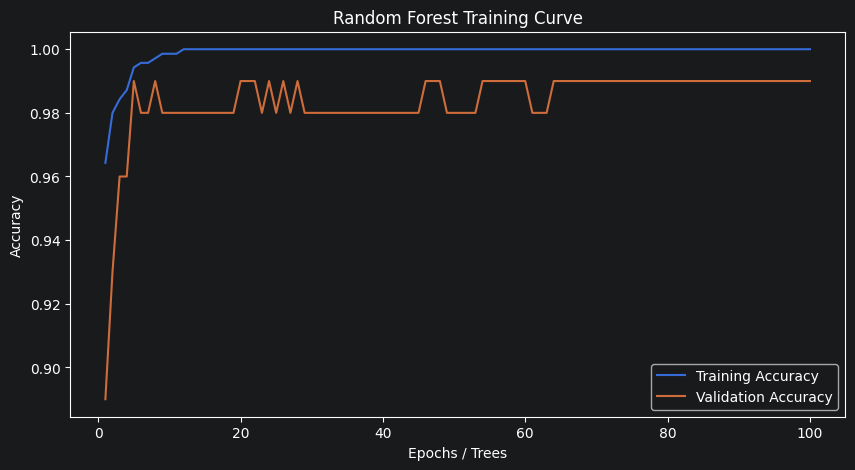

In [13]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=epochs_range,
    y=rf_train_acc,
    label="Training Accuracy"
)

sns.lineplot(
    x=epochs_range,
    y=rf_val_acc,
    label="Validation Accuracy"
)

plt.title("Random Forest Training Curve")

plt.xlabel("Epochs / Trees")

plt.ylabel("Accuracy")

plt.legend()

plt.show()